# Inspect the trained match-result model

Loads the Booster saved by `training/train_match_result.py` and answers three questions:

1. Which features contributed most to match-result predictions?
2. What do the individual decision trees look like?
3. How does the serving `/predict-match` endpoint score one matchup?

## 1. Load the saved Booster

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import xgboost as xgb

MODEL_PATH = Path('..') / 'serving' / 'models' / 'match_result_model.ubj'

model = xgb.Booster()
model.load_model(str(MODEL_PATH))
print(f'Loaded {MODEL_PATH}')
print(f'Features: {model.feature_names}')
print(f'Number of trees: {model.num_boosted_rounds()}')

Loaded ../serving/models/match_result_model.ubj
Features: ['home_matches_played', 'home_wins', 'home_draws', 'home_losses', 'home_goals_for', 'home_goals_against', 'away_matches_played', 'away_wins', 'away_draws', 'away_losses', 'away_goals_for', 'away_goals_against', 'odds_pinnacle_home', 'odds_pinnacle_draw', 'odds_pinnacle_away']
Number of trees: 100


## 2. Feature importance

Three importance types worth comparing:

- **gain** — average loss reduction when a feature is used in a split. Usually the most meaningful.
- **weight** — how often the feature appears in a split (count).
- **cover** — average number of samples touched by splits on that feature.

In [50]:
import pandas as pd

rows = []
for itype in ('gain', 'weight', 'cover'):
    scores = model.get_score(importance_type=itype)
    for feat, score in scores.items():
        rows.append({'feature': feat, 'type': itype, 'score': score})

importance_df = (
    pd.DataFrame(rows)
    .pivot(index='feature', columns='type', values='score')
    .fillna(0)
    .sort_values('gain', ascending=False)
)
importance_df

type,cover,gain,weight
feature,,,
odds_pinnacle_away,831.540039,5.614622,272.0
odds_pinnacle_home,633.851990,4.454590,341.0
away_goals_for,454.276123,2.108476,160.0
away_losses,412.175934,2.090320,235.0
away_wins,292.401215,2.083034,220.0
away_goals_against,452.992004,1.940658,223.0
home_goals_against,403.921997,1.900354,196.0
odds_pinnacle_draw,627.570435,1.869022,403.0
home_wins,579.067871,1.839246,196.0


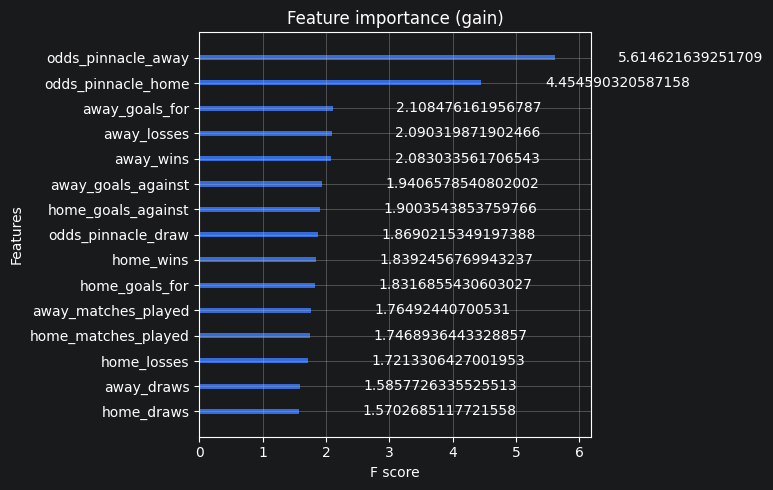

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
xgb.plot_importance(model, importance_type='gain', ax=ax, title='Feature importance (gain)')
plt.tight_layout()
plt.show()

## 3. Visualize a decision tree

`to_graphviz` renders inline in the notebook (requires the `graphviz` system package — `brew install graphviz`).
Pick a tree by index; with `num_boost_round=50` you have trees `0..49`.

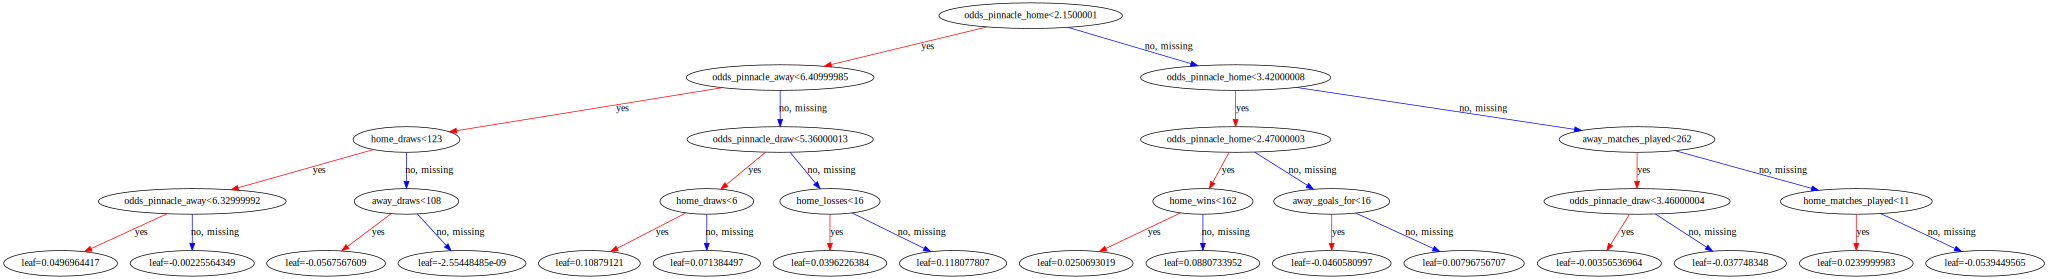

In [52]:
TREE_INDEX = 0
xgb.to_graphviz(model, num_trees=TREE_INDEX)

### Text dump (no graphviz needed)

Each line is `node_id:[split condition] yes=… no=…` or a leaf with its score.

In [53]:
dump = model.get_dump(with_stats=True)
print(f'Tree {TREE_INDEX}:\n')
print(dump[TREE_INDEX])

Tree 0:

0:[odds_pinnacle_home<2.1500001] yes=1,no=2,missing=2,gain=141.253571,cover=1914.6665
	1:[odds_pinnacle_away<6.40999985] yes=3,no=4,missing=4,gain=25.0318604,cover=1026.66663
		3:[home_draws<123] yes=7,no=8,missing=8,gain=4.28701782,cover=657.77771
			7:[odds_pinnacle_away<6.32999992] yes=15,no=16,missing=16,gain=3.66278076,cover=653.333313
				15:leaf=0.0496964417,cover=639.555542
				16:leaf=-0.00225564349,cover=13.7777767
			8:[away_draws<108] yes=17,no=18,missing=18,gain=0.324324369,cover=4.44444418
				17:leaf=-0.0567567609,cover=3.11111093
				18:leaf=-2.55448485e-09,cover=1.33333325
		4:[odds_pinnacle_draw<5.36000013] yes=9,no=10,missing=10,gain=5.43154907,cover=368.888855
			9:[home_draws<6] yes=19,no=20,missing=20,gain=3.27664185,cover=316.444427
				19:leaf=0.10879121,cover=29.3333321
				20:leaf=0.071384497,cover=287.111084
			10:[home_losses<16] yes=21,no=22,missing=22,gain=2.0091629,cover=52.4444427
				21:leaf=0.0396226384,cover=4.88888836
				22:leaf=0.118077807

## 4. Per-match explanations with SHAP

Global importance tells us which features matter on average. SHAP values break down a single matchup:
how much each feature pushed the class score up or down from the baseline. Useful when importance is spread
across home-team form, away-team form, and odds, and you need to justify *this specific* prediction.

In [54]:
import shap

TEAM_FEATURES = ['matches_played', 'wins', 'draws', 'losses', 'goals_for', 'goals_against']
ODDS_FEATURES = ['odds_pinnacle_home', 'odds_pinnacle_draw', 'odds_pinnacle_away']
FEATURES = model.feature_names or [f'home_{f}' for f in TEAM_FEATURES] + [f'away_{f}' for f in TEAM_FEATURES] + ODDS_FEATURES
TEAM_STATS_PATH = Path('..') / 'data/offline_store/team_stats/team_stats.parquet'
MATCHES_PATH = Path('..') / 'data/offline_store/matches'

team_stats = pd.read_parquet(TEAM_STATS_PATH)
team_stats = team_stats.sort_values('event_timestamp').groupby('team_name').last()
team_stats = team_stats[team_stats['matches_played'] > 0]

matches = pd.read_parquet(MATCHES_PATH)
matches = matches.dropna(subset=ODDS_FEATURES).tail(250).reset_index(drop=True)

rows = []
for match in matches.itertuples(index=False):
    home_team = match.home_team
    away_team = match.away_team
    if home_team not in team_stats.index or away_team not in team_stats.index:
        continue

    row = {f"home_{f}": team_stats.loc[home_team, f] for f in TEAM_FEATURES}
    row.update({f"away_{f}": team_stats.loc[away_team, f] for f in TEAM_FEATURES})
    row.update({f: getattr(match, f) for f in ODDS_FEATURES})
    rows.append(row)

X = pd.DataFrame(rows, columns=FEATURES).astype(float)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
print(f'Computed SHAP values for {len(X)} matchups')

Computed SHAP values for 250 matchups


### Waterfall: explain one `/predict-match` response

Pick a home team, away team, and odds. The first call hits the local serving API, then the waterfall uses the
same feature vector with the local Booster to show which inputs moved one class score away from baseline.

sao_paulo vs santos
Prediction: A
Probabilities: {'H': 0.10205353796482086, 'D': 0.22852003574371338, 'A': 0.669426441192627}


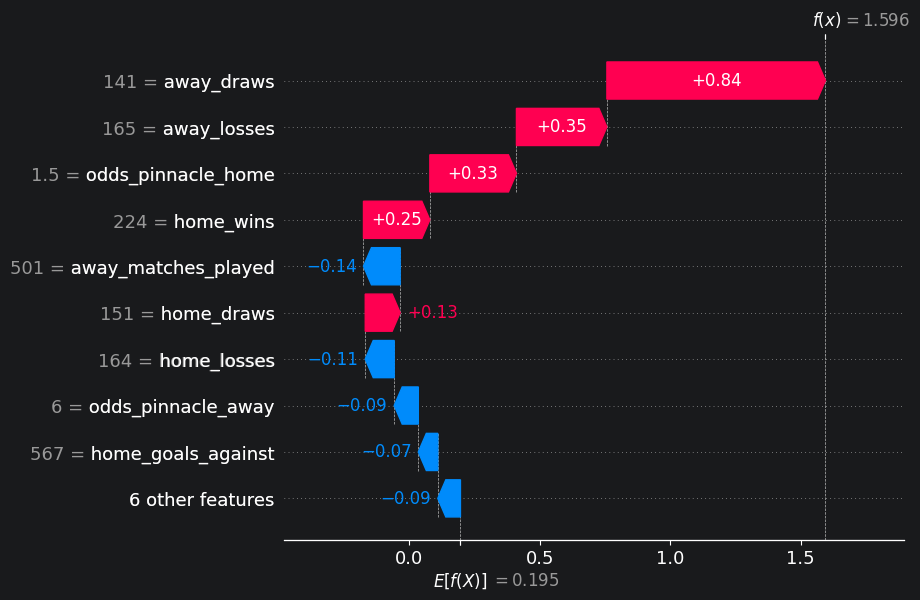

In [55]:
import requests

PREDICT_MATCH_URL = 'http://localhost:8000/predict-match'
payload = {
    'home_team': 'sao_paulo',
    'away_team': 'santos',
    'odds_pinnacle_home': 1.5,
    'odds_pinnacle_draw': 4.0,
    'odds_pinnacle_away': 6.0,
}

response = requests.post(PREDICT_MATCH_URL, json=payload, timeout=10)
response.raise_for_status()
prediction = response.json()

match_features = {f"home_{f}": team_stats.loc[payload["home_team"], f] for f in TEAM_FEATURES}
match_features.update({f"away_{f}": team_stats.loc[payload["away_team"], f] for f in TEAM_FEATURES})
match_features.update({f: payload[f] for f in ODDS_FEATURES})
sample = pd.DataFrame([match_features], columns=FEATURES).astype(float)

class_index = ["H", "D", "A"].index(prediction["prediction"])
sample_shap = explainer(sample)

print(f'{prediction["home_team"]} vs {prediction["away_team"]}')
print(f'Prediction: {prediction["prediction"]}')
print(f'Probabilities: {prediction["probabilities"]}')
shap.plots.waterfall(sample_shap[0, :, class_index])

### Beeswarm: how features behave across matchups

Each dot is one matchup. Position on the x-axis is that matchup's SHAP value for the selected result class;
color is the feature value. This reveals patterns across home-team form, away-team form, and odds.

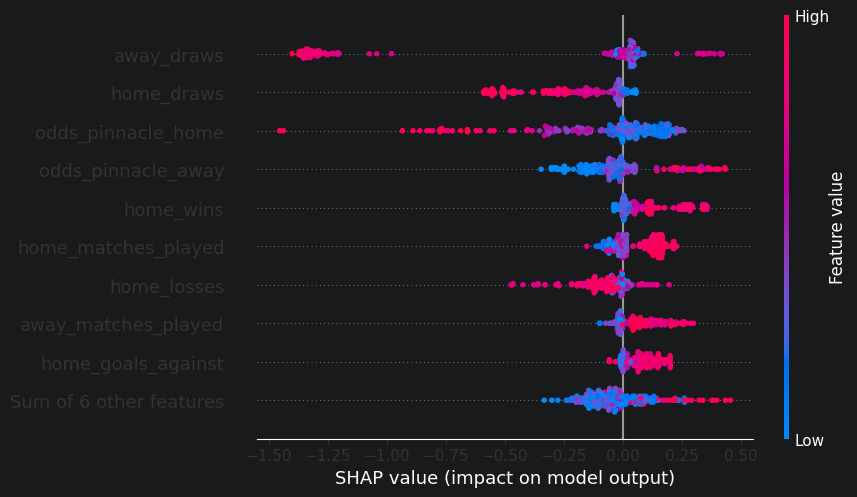

In [56]:
CLASS_TO_EXPLAIN = 'H'
class_index = ['H', 'D', 'A'].index(CLASS_TO_EXPLAIN)
shap.plots.beeswarm(shap_values[:, :, class_index])